# XGBoost 분류 모델
## 한국 반도체 주가 등락 예측

- **데이터**: `data/features_dataset.csv` (8개 종목, 2022~2024)
- **타겟**: 다음 거래일 종가 등락 여부 (상승=1, 하락=0, 보합 제외)
- **피처**: 기술적 지표 10개 + 거시경제 7개 + 재무비율 4개 = **총 21개**
- **분할 방식**: 시계열 기반 (훈련 80% / 테스트 20%)

## 1. 라이브러리 임포트

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay
)

def set_korean_font():
    candidates = ['Malgun Gothic', 'NanumGothic', 'AppleGothic']
    for name in candidates:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams['font.family'] = name
            break
    plt.rcParams['axes.unicode_minus'] = False

set_korean_font()
print(f"XGBoost 버전: {xgb.__version__}")

XGBoost 버전: 3.2.0


## 2. 데이터 로딩 및 시계열 분할

In [2]:
BASE      = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
DATA_PATH = os.path.join(BASE, 'data', 'features_dataset.csv')

df = pd.read_csv(DATA_PATH, encoding='utf-8-sig')
df['날짜'] = pd.to_datetime(df['날짜'])
df = df.sort_values('날짜').reset_index(drop=True)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df = df.reset_index(drop=True)

drop_cols = ['날짜', '종목명', '종목코드', 'target']
X = df.drop(columns=drop_cols)
y = df['target']
dates = df['날짜']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"전체 데이터: {len(df):,}행  |  피처: {X.shape[1]}개")
print(f"훈련 기간  : {dates.iloc[0].date()} ~ {dates.iloc[split_idx-1].date()}  ({len(X_train):,}행)")
print(f"테스트 기간: {dates.iloc[split_idx].date()} ~ {dates.iloc[-1].date()}  ({len(X_test):,}행)")

전체 데이터: 5,687행  |  피처: 21개
훈련 기간  : 2022-01-03 ~ 2024-05-28  (4,549행)
테스트 기간: 2024-05-28 ~ 2024-12-30  (1,138행)


## 3. 모델 학습

XGBoost는 이전 트리의 오차를 보정하며 순차적으로 트리를 쌓는 **그래디언트 부스팅** 방식입니다.  
Random Forest보다 오차 수정에 집중하므로 일반적으로 성능이 더 높습니다.

In [3]:
# 클래스 불균형 비율 계산 (scale_pos_weight 파라미터용)
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_pos_weight = neg_count / pos_count
print(f"하락(0): {neg_count}  |  상승(1): {pos_count}  |  scale_pos_weight: {scale_pos_weight:.3f}")

model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,           # 매 트리마다 80% 샘플 사용 (과적합 방지)
    colsample_bytree=0.8,    # 매 트리마다 80% 피처 사용 (과적합 방지)
    scale_pos_weight=scale_pos_weight,  # 클래스 불균형 보정
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train, y_train)
print("학습 완료")

하락(0): 2380  |  상승(1): 2169  |  scale_pos_weight: 1.097


C:\Users\USER\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:05:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


학습 완료


## 4. 성능 평가

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall'   : recall_score(y_test, y_pred, zero_division=0),
    'F1'       : f1_score(y_test, y_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, y_prob),
}

print("=" * 35)
print(f"  {'지표':<12} {'값':>8}")
print("=" * 35)
for k, v in metrics.items():
    print(f"  {k:<12} {v:>8.4f}")
print("=" * 35)

print("\n[Classification Report]")
print(classification_report(y_test, y_pred,
                            target_names=['하락(0)', '상승(1)'],
                            zero_division=0))

  지표                  값
  Accuracy       0.4886
  Precision      0.4492
  Recall         0.5269
  F1             0.4850
  ROC-AUC        0.4964

[Classification Report]
              precision    recall  f1-score   support

       하락(0)       0.53      0.46      0.49       618
       상승(1)       0.45      0.53      0.48       520

    accuracy                           0.49      1138
   macro avg       0.49      0.49      0.49      1138
weighted avg       0.50      0.49      0.49      1138



## 5. 혼동 행렬 (Confusion Matrix)

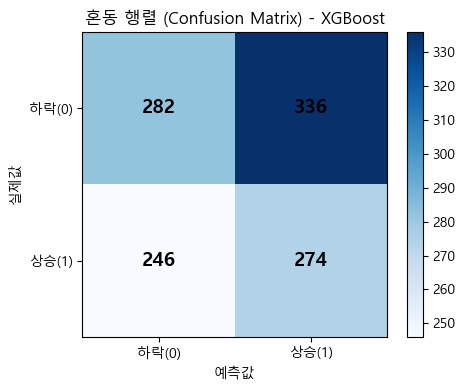

In [5]:
cm = confusion_matrix(y_test, y_pred)
labels = ['하락(0)', '상승(1)']

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel('예측값'); ax.set_ylabel('실제값')
ax.set_title('혼동 행렬 (Confusion Matrix) - XGBoost')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='black' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## 6. ROC Curve

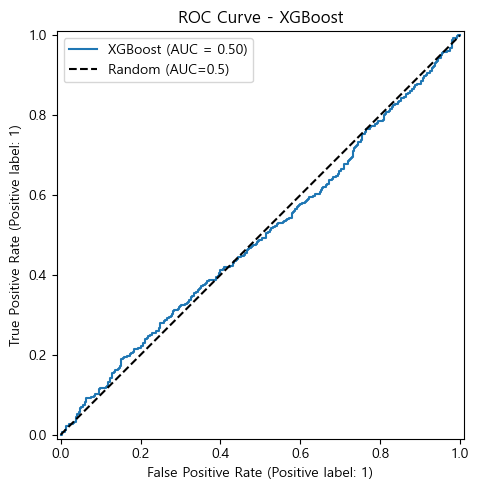

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name='XGBoost')
ax.plot([0, 1], [0, 1], 'k--', label='Random (AUC=0.5)')
ax.set_title('ROC Curve - XGBoost')
ax.legend()
plt.tight_layout()
plt.show()

## 7. 피처 중요도 Top 10

XGBoost의 피처 중요도는 각 피처가 트리 분기에 사용된 횟수(weight) 기준입니다.

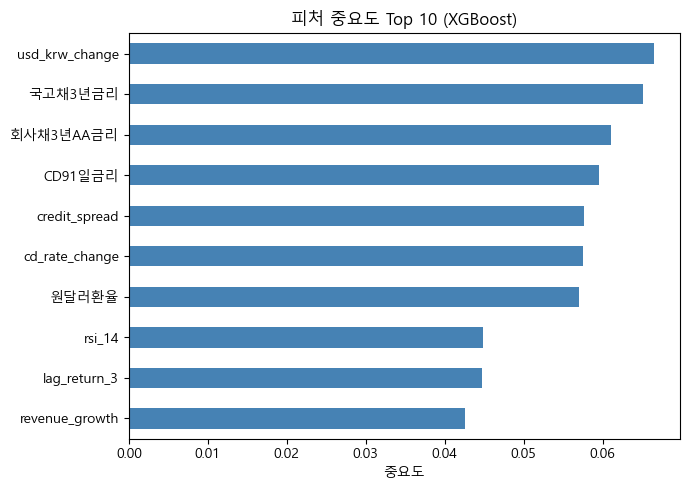


피처 중요도 순위:
   1. usd_krw_change            0.0665
   2. 국고채3년금리                   0.0651
   3. 회사채3년AA금리                 0.0611
   4. CD91일금리                   0.0596
   5. credit_spread             0.0576
   6. cd_rate_change            0.0575
   7. 원달러환율                     0.0570
   8. rsi_14                    0.0449
   9. lag_return_3              0.0448
  10. revenue_growth            0.0426


In [7]:
importances = pd.Series(model.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('피처 중요도 Top 10 (XGBoost)')
ax.set_xlabel('중요도')
plt.tight_layout()
plt.show()

print("\n피처 중요도 순위:")
for i, (feat, val) in enumerate(top10.items(), 1):
    print(f"  {i:2d}. {feat:<25} {val:.4f}")